# Half-subs GNN training diagnostics

Per-epoch curves and best-epoch summaries for the 8 [`HalfSubsGNN`](../gnn_subs.py) variants under [`artifacts/half_subs/gnn_subs_*`](../../artifacts/half_subs/). All plotting/loading helpers live in [`../training_diagnostics.py`](../training_diagnostics.py) - this notebook just calls them.

Each `gnn_subs_*` run writes a [`log.jsonl`](../../artifacts/half_subs/gnn_subs_archetype_paired_coords_stats/log.jsonl) with one record per epoch (train MSE, val MSE/MAE/R²/Pearson/Spearman/sign-acc, grad norm, LR, epoch seconds). Tabular runs only emit `summary.json` + `test_preds.parquet`, so per-iteration curves only exist for the 8 GNN variants.

Color encodes **kind** (position = blue, archetype = red), linestyle encodes **mode** (single = solid, paired = dashed), and alpha encodes **stats** (with-stats = bold, no-stats = faded) - so the legend reads as the 2x2x2 design grid rather than 8 arbitrary lines.

In [1]:
from __future__ import annotations
import sys
from pathlib import Path

# Make repo root importable when running from models/notebooks/.
ROOT = Path.cwd().resolve()
while not (ROOT / 'models' / 'training_diagnostics.py').exists():
    if ROOT == ROOT.parent:
        raise RuntimeError('repo root not found')
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import pandas as pd

from models.training_diagnostics import (
    best_epoch_table,
    load_all_logs,
    plot_epoch_timing,
    plot_grad_norms,
    plot_loss_curves,
    plot_metric_overlays,
)

logs = load_all_logs(ROOT / 'artifacts' / 'half_subs')
{k: df.shape for k, df in logs.items()}

{'gnn_subs_archetype_paired_coords': (30, 13),
 'gnn_subs_archetype_paired_coords_stats': (30, 13),
 'gnn_subs_archetype_single_coords': (30, 13),
 'gnn_subs_archetype_single_coords_stats': (30, 13),
 'gnn_subs_position_paired_coords': (30, 13),
 'gnn_subs_position_paired_coords_stats': (30, 13),
 'gnn_subs_position_single_coords': (30, 13),
 'gnn_subs_position_single_coords_stats': (30, 13)}

## Best-epoch summary

One row per run, sorted by best val MSE. `best epoch` is the early-stopping pick; `total minutes` is the wall-clock cost of the full 30-epoch run (best epoch is usually well before the end).

In [2]:
pd.set_option('display.width', 200)
best_epoch_table(logs).round(4)

,run,best epoch,train MSE,val MSE,val MAE,val R²,val Pearson,val sign acc,epochs run,total minutes
0,arch · paired · stats,27,0.1895,0.1871,0.3202,0.2826,0.5317,0.6592,30,123.3272
1,arch · single · stats,8,0.1971,0.1902,0.3217,0.2706,0.5203,0.6519,30,93.0346
2,pos · paired · stats,5,0.2025,0.1963,0.3269,0.2473,0.4989,0.6498,30,78.5597
3,pos · single · stats,21,0.1957,0.1969,0.3276,0.2450,0.4968,0.6352,30,212.5334
4,arch · single,9,0.2012,0.2126,0.3415,0.1848,0.4317,0.6174,30,41.8019
5,arch · paired,5,0.2204,0.2153,0.3419,0.1744,0.4177,0.6067,30,62.0550
6,pos · single,13,0.2468,0.2534,0.3623,0.0285,0.1687,0.5459,30,134.6417
7,pos · paired,19,0.2483,0.2574,0.3648,0.0132,0.1237,0.5326,30,124.3601


## Train vs val MSE per epoch

Best epoch (= min val MSE) marked with a black-rimmed dot on the val panel. A widening gap between train and val signals overfitting - use this to decide whether 30 epochs is too many for any variant.

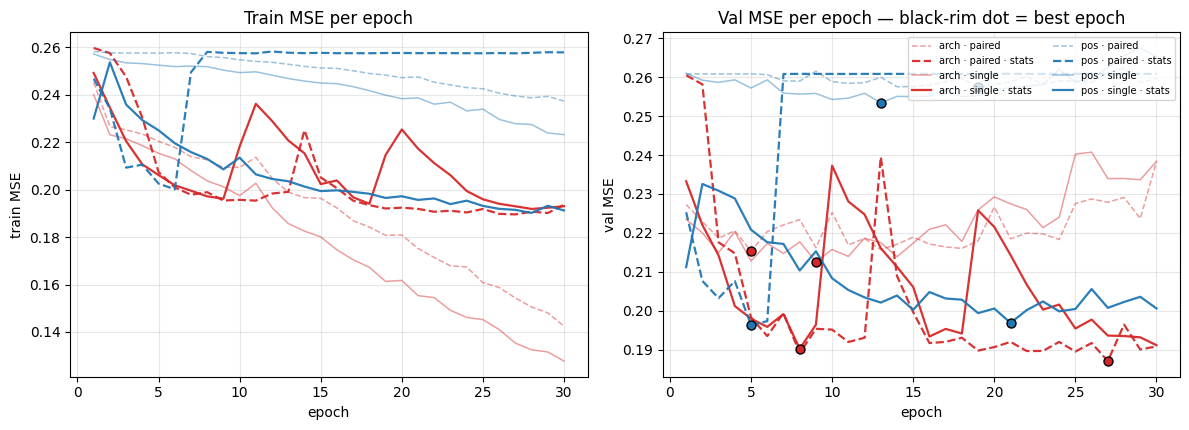

In [3]:
fig = plot_loss_curves(logs)

## Validation R², Pearson r, sign accuracy per epoch

Same 8 runs overlaid. R² and Pearson typically peak near the val-MSE minimum; sign accuracy is the metric the per-30 xG-diff prediction ultimately gets judged on for win/draw/loss tilt.

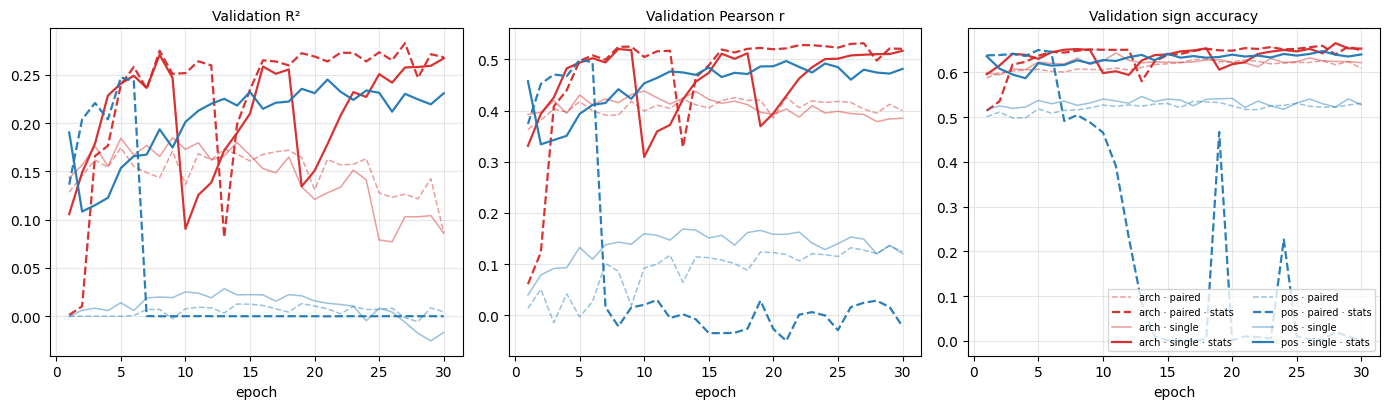

In [4]:
fig = plot_metric_overlays(logs)

## Mean gradient norm

Surfaces training instability: a sharp spike after the loss starts dropping usually means the model entered an aggressive-update regime around the same time the train/val gap began to open. Useful for deciding whether to lower LR or add gradient clipping.

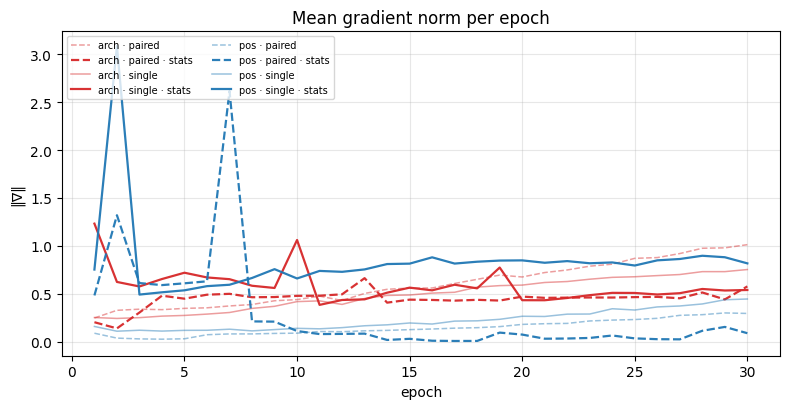

In [5]:
fig = plot_grad_norms(logs)

## Wall-clock seconds per epoch

Per-epoch runtime - flags machine contention rather than model quality. Spikes here track CPU/GPU pressure from other processes, not anything model-side. Use it to sanity-check why a given run took 2x longer than its peers.

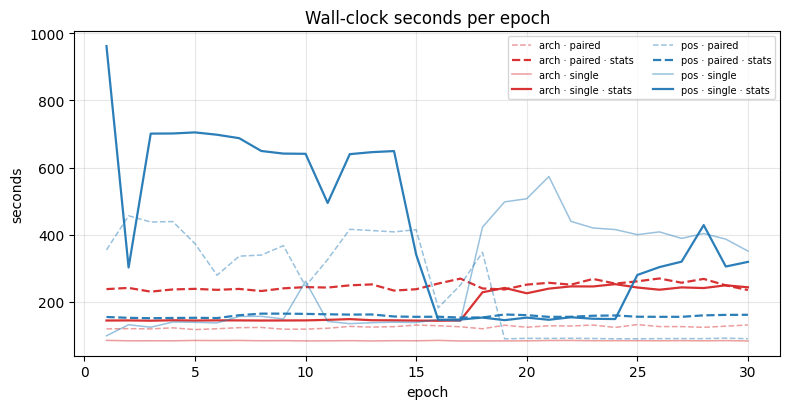

In [6]:
fig = plot_epoch_timing(logs)